In [1]:
pip install monai loguru kagglehub scikit-learn

In [2]:
import os
import torch
import tarfile
import numpy as np
from pathlib import Path
from tqdm import tqdm
import kagglehub

from monai.networks.nets import AttentionUnet
from monai.networks.layers import Norm
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd,
    NormalizeIntensityd, RandFlipd, RandAffined, Resized, EnsureTyped,
    MapLabelValued, AsDiscrete
)
from monai.data import Dataset, DataLoader

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [ ]:
CONFIG = {
    "batch_size": 16,
    "image_size": (128, 128, 128),
    "num_epochs": 100,
    "learning_rate": 1e-4,
    "val_split": 0.2,
    "val_interval": 5,
    "early_stop_patience": 6,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "grad_clip_norm": 1.0,
    "num_workers": 2,
    "pin_memory": True,
}

print(f"Using device: {CONFIG['device']}")

Using device: cuda


In [4]:
DATA_DIR = kagglehub.dataset_download("dschettler8845/brats-2021-task1")
print(f"Dataset downloaded to: {DATA_DIR}")

Using Colab cache for faster access to the 'brats-2021-task1' dataset.
Dataset downloaded to: /kaggle/input/brats-2021-task1


In [ ]:
# Extract
data_path = Path(DATA_DIR)
extract_path = Path("BraTS2021_extracted")
extract_path.mkdir(parents=True, exist_ok=True)

training_tar = data_path / "BraTS2021_Training_Data.tar"
print("Extracting BraTS2021_Training_Data.tar ...")

with tarfile.open(training_tar, 'r') as tar:
    for member in tqdm(tar.getmembers(), desc="Extracting"):
        tar.extract(member, path=extract_path)

print("✅ Extraction completed.")

# Use the extracted folder directly
training_path = extract_path

print(f"Training path: {training_path}")

# Build file list
patient_dirs = sorted([d for d in training_path.iterdir()
                      if d.is_dir() and d.name.startswith("BraTS2021")])

all_files = []
for p_dir in tqdm(patient_dirs, desc="Building dataset"):
    p_id = p_dir.name
    all_files.append({
        "image": str(p_dir / f"{p_id}_flair.nii.gz"),
        "label": str(p_dir / f"{p_id}_seg.nii.gz")
    })

print(f"\nTotal patients found: {len(all_files)}")

# Split
num_train = int(len(all_files) * 0.8)
train_files = all_files[:num_train]
val_files = all_files[num_train:]

print(f"Train: {len(train_files)} | Val: {len(val_files)}")

Extracting BraTS2021_Training_Data.tar ...


Extracting:   0%|          | 0/7508 [00:00<?, ?it/s]/tmp/ipykernel_3390/2478348459.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=extract_path)
Extracting: 100%|██████████| 7508/7508 [01:04<00:00, 116.19it/s]


✅ Extraction completed.
Training path: BraTS2021_extracted


Building dataset: 100%|██████████| 1251/1251 [00:00<00:00, 151321.54it/s]


Total patients found: 1251
Train: 1000 | Val: 251


In [6]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    MapLabelValued(keys=["label"], orig_labels=[1, 2, 4], target_labels=[1, 1, 1]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Resized(keys=["image", "label"], spatial_size=CONFIG["image_size"], mode=("trilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0, 1, 2]),
    RandAffined(keys=["image", "label"], prob=0.5, rotate_range=0.1, scale_range=0.1, translate_range=5),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    MapLabelValued(keys=["label"], orig_labels=[1, 2, 4], target_labels=[1, 1, 1]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Resized(keys=["image", "label"], spatial_size=CONFIG["image_size"], mode=("trilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image", "label"]),
])

train_ds = Dataset(train_files, train_transforms)
val_ds = Dataset(val_files, val_transforms)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                         num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                       num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
model = AttentionUnet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    dropout=0.2,
).to(CONFIG["device"])

total_params = sum(p.numel() for p in model.parameters())
print(f"Attention UNet parameters: {total_params:,} ({total_params/1e6:.2f}M)")

loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
dice_metric = DiceMetric(include_background=False, reduction="mean")

# AMP
scaler = torch.amp.GradScaler('cuda')

# ========================= TRAINING =========================
best_dice = 0.0
patience_counter = 0

for epoch in range(CONFIG["num_epochs"]):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}")

    for batch in progress_bar:
        inputs = batch["image"].to(CONFIG["device"])
        labels = batch["label"].to(CONFIG["device"])

        optimizer.zero_grad()

        with torch.autocast(device_type=CONFIG["device"], dtype=torch.float16):
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip_norm"])
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}")

    # Validation
    if (epoch + 1) % CONFIG["val_interval"] == 0:
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val_batch in tqdm(val_loader, desc="Validating"):
                v_inputs = val_batch["image"].to(CONFIG["device"])
                v_labels = val_batch["label"].to(CONFIG["device"])

                v_outputs = model(v_inputs)

                post_pred = AsDiscrete(argmax=True, to_onehot=2, dim=1)(v_outputs)
                post_label = AsDiscrete(to_onehot=2, dim=1)(v_labels)

                dice_metric(y_pred=post_pred, y=post_label)

        metric = dice_metric.aggregate().item()
        print(f"Validation Dice: {metric:.4f}")

        if metric > best_dice:
            best_dice = metric
            torch.save(model.state_dict(), "best_3d_unet_brats.pth")
            print("✓ New best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["early_stop_patience"]:
                print("Early stopping triggered.")
                break

print(f"\nTraining finished! Best Dice: {best_dice:.4f}")

Attention UNet parameters: 23,625,986 (23.63M)


Epoch 1/100: 100%|██████████| 63/63 [02:00<00:00,  1.91s/it, loss=1.0725]


Epoch 1 - Avg Loss: 1.2061


Epoch 2/100: 100%|██████████| 63/63 [02:01<00:00,  1.93s/it, loss=1.0449]


Epoch 2 - Avg Loss: 1.0434


...

Epoch 99 - Avg Loss: 0.0660


Epoch 100/100: 100%|██████████| 63/63 [02:00<00:00,  1.91s/it, loss=0.0714]


Epoch 100 - Avg Loss: 0.0644


Validating: 100%|██████████| 16/16 [00:22<00:00,  1.43s/it]

Validation Dice: 0.8952
✓ New best model saved!

Training finished! Best Dice: 0.8952


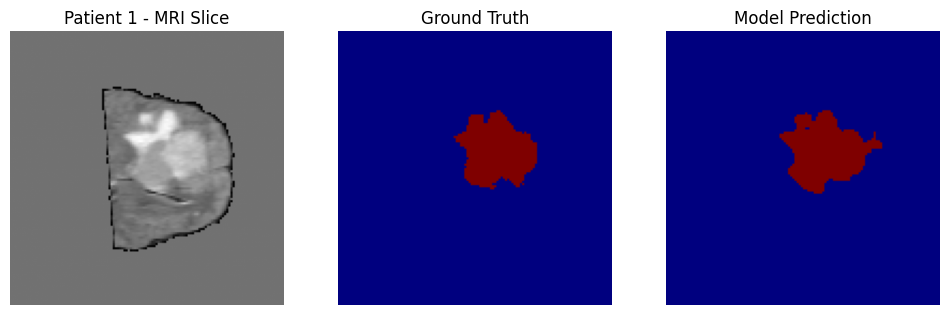

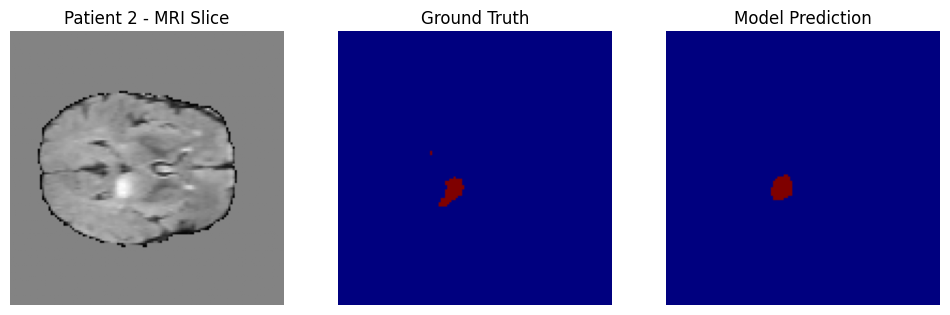

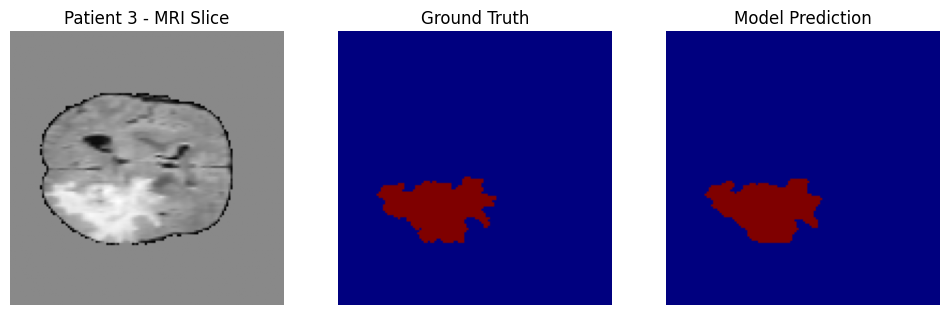

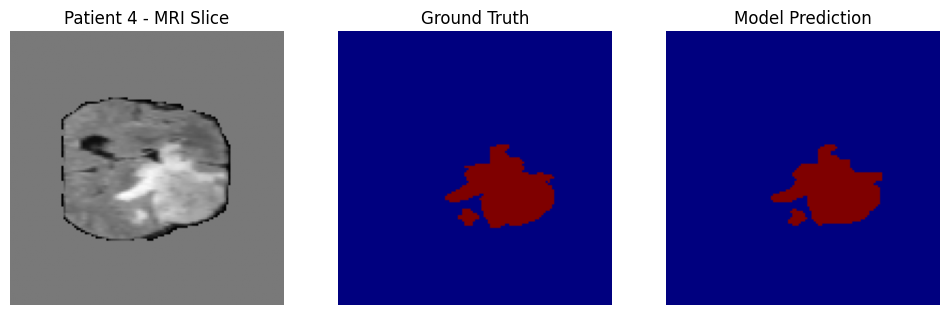

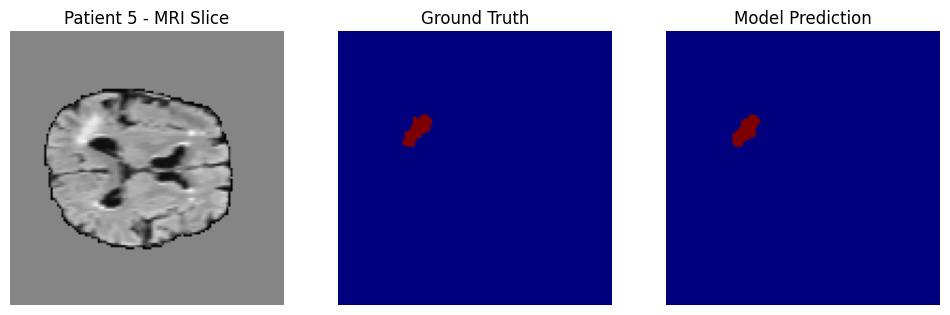

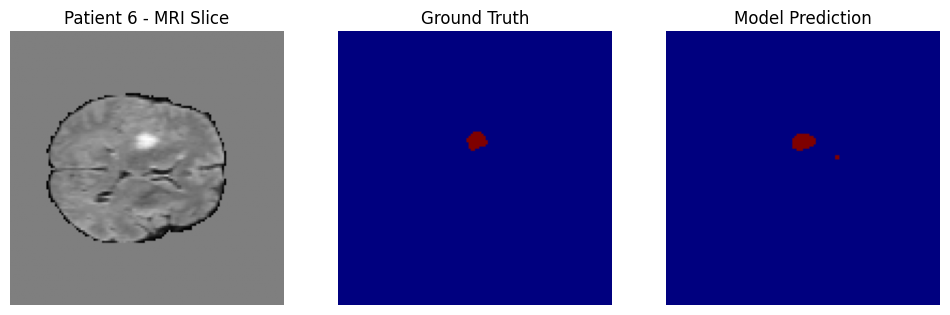

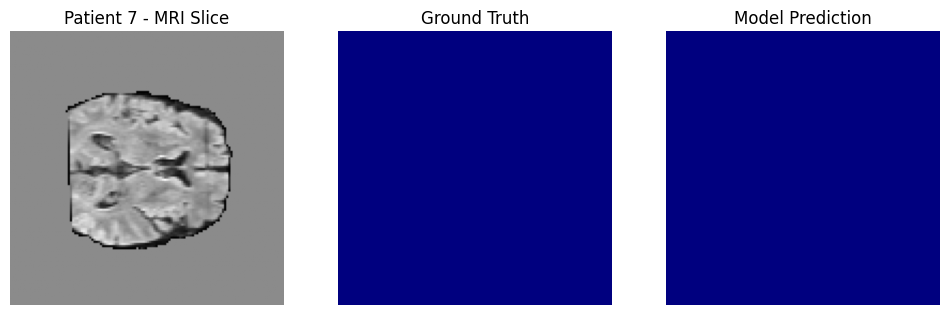

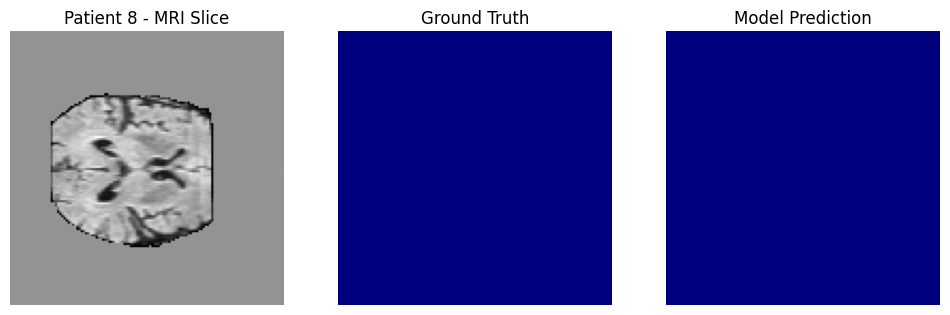

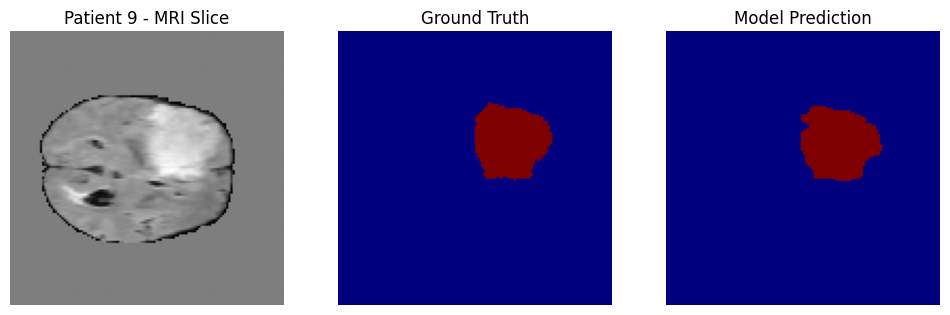

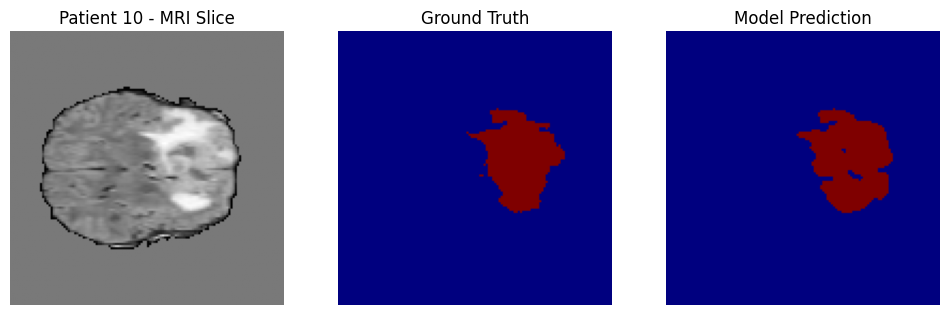

In [9]:
import matplotlib.pyplot as plt

def test_and_visualize(model_path, val_files, num_samples=10):
    # 1. Load the best saved model
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 2. Pick a few samples from the validation set
    test_ds = Dataset(data=val_files[:num_samples], transform=val_transforms)
    test_loader = DataLoader(test_ds, batch_size=1)

    device = CONFIG["device"]

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            inputs = batch["image"].to(device)
            labels = batch["label"].to(device)

            # Inference
            outputs = model(inputs)

            # Post-processing to get binary mask
            # We use argmax(1) to pick the most likely class (Background vs Tumor)
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            img_data = inputs.cpu().numpy()[0, 0]  # Get first channel
            label_data = labels.cpu().numpy()[0, 0] # Get ground truth

            # 3. Visualize the middle slice of the 3D volume
            slice_idx = CONFIG["image_size"][2] // 2

            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.title(f"Patient {i+1} - MRI Slice")
            plt.imshow(img_data[:, :, slice_idx], cmap="gray")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Ground Truth")
            plt.imshow(label_data[:, :, slice_idx], cmap="jet")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Model Prediction")
            plt.imshow(preds[0, :, :, slice_idx], cmap="jet")
            plt.axis('off')

            plt.show()

# Run the test
test_and_visualize("best_3d_unet_brats.pth", val_files)